## Data Investigation

In [10]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data.csv")
df.head(5)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,...,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,?,5.2006,...,no,no,no,8,yes,0,0.00,?,?,?
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,...,yes,no,no,13,yes,0,0.00,?,?,?
2,49923,no,yes,no,4/3/1972,yes,no,check,?,12.2007,...,no,no,no,3,yes,0,0.00,?,?,?
3,49924,no,no,yes,8/1/1966,yes,no,check,?,1.2007,...,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,...,no,no,no,16,yes,0,0.00,?,?,?


In [5]:
df.shape

(30000, 44)

In [6]:
df.describe()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25032.612933,6.680567,43.968058,1.442200,331860.254033,8.577900,0.606700,29.875652
std,14422.306098,3.468332,35.709431,0.921496,147310.846584,3.863448,0.765616,57.382732
min,1.000000,1.200500,5.200000,1.000000,100061.000000,1.000000,0.000000,0.000000
25%,12518.750000,3.200700,17.990000,1.000000,204159.000000,6.000000,0.000000,0.000000
50%,25095.500000,6.200700,34.500000,1.000000,401241.000000,9.000000,0.000000,0.000000
75%,37520.250000,10.200500,57.800000,2.000000,407703.000000,11.000000,1.000000,38.470000
max,50000.000000,12.200700,361.200000,9.000000,609725.000000,24.000000,6.000000,1047.800000


In [8]:
df.dtypes

ORDER_ID               int64
CLASS                    str
B_EMAIL                  str
B_TELEFON                str
B_BIRTHDATE              str
FLAG_LRIDENTISCH         str
FLAG_NEWSLETTER          str
Z_METHODE                str
Z_CARD_ART               str
Z_CARD_VALID         float64
Z_LAST_NAME              str
VALUE_ORDER          float64
WEEKDAY_ORDER            str
TIME_ORDER               str
AMOUNT_ORDER           int64
ANUMMER_01             int64
ANUMMER_02               str
ANUMMER_03               str
ANUMMER_04               str
ANUMMER_05               str
ANUMMER_06               str
ANUMMER_07               str
ANUMMER_08               str
ANUMMER_09               str
ANUMMER_10               str
CHK_LADR                 str
CHK_RADR                 str
CHK_KTO                  str
CHK_CARD                 str
CHK_COOKIE               str
CHK_IP                   str
FAIL_LPLZ                str
FAIL_LORT                str
FAIL_LPLZORTMATCH        str
FAIL_RPLZ     

In [12]:
df.head(5)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,Z_LAST_NAME,VALUE_ORDER,WEEKDAY_ORDER,TIME_ORDER,AMOUNT_ORDER,ANUMMER_01,ANUMMER_02,ANUMMER_03,ANUMMER_04,ANUMMER_05,ANUMMER_06,ANUMMER_07,ANUMMER_08,ANUMMER_09,ANUMMER_10,CHK_LADR,CHK_RADR,CHK_KTO,CHK_CARD,CHK_COOKIE,CHK_IP,FAIL_LPLZ,FAIL_LORT,FAIL_LPLZORTMATCH,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,?,5.2006,?,17.80,Saturday,9:13:00 AM,1,406811,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,8,yes,0,0.00,?,?,?
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,yes,18.20,Wednesday,5:36:00 PM,1,600953,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,yes,no,no,13,yes,0,0.00,?,?,?
2,49923,no,yes,no,4/3/1972,yes,no,check,?,12.2007,?,10.80,Friday,11:13:00 AM,1,406310,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,3,yes,0,0.00,?,?,?
3,49924,no,no,yes,8/1/1966,yes,no,check,?,1.2007,?,54.50,Friday,2:07:00 AM,1,307359,?,?,?,?,?,?,?,?,?,no,no,no,yes,no,no,no,no,no,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,yes,19.99,Tuesday,11:46:00 PM,1,200767,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,16,yes,0,0.00,?,?,?


In [13]:
# info on dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ORDER_ID           30000 non-null  int64  
 1   CLASS              30000 non-null  str    
 2   B_EMAIL            30000 non-null  str    
 3   B_TELEFON          30000 non-null  str    
 4   B_BIRTHDATE        30000 non-null  str    
 5   FLAG_LRIDENTISCH   30000 non-null  str    
 6   FLAG_NEWSLETTER    30000 non-null  str    
 7   Z_METHODE          30000 non-null  str    
 8   Z_CARD_ART         30000 non-null  str    
 9   Z_CARD_VALID       30000 non-null  float64
 10  Z_LAST_NAME        30000 non-null  str    
 11  VALUE_ORDER        30000 non-null  float64
 12  WEEKDAY_ORDER      30000 non-null  str    
 13  TIME_ORDER         29980 non-null  str    
 14  AMOUNT_ORDER       30000 non-null  int64  
 15  ANUMMER_01         30000 non-null  int64  
 16  ANUMMER_02         30000 non-null

<Axes: >

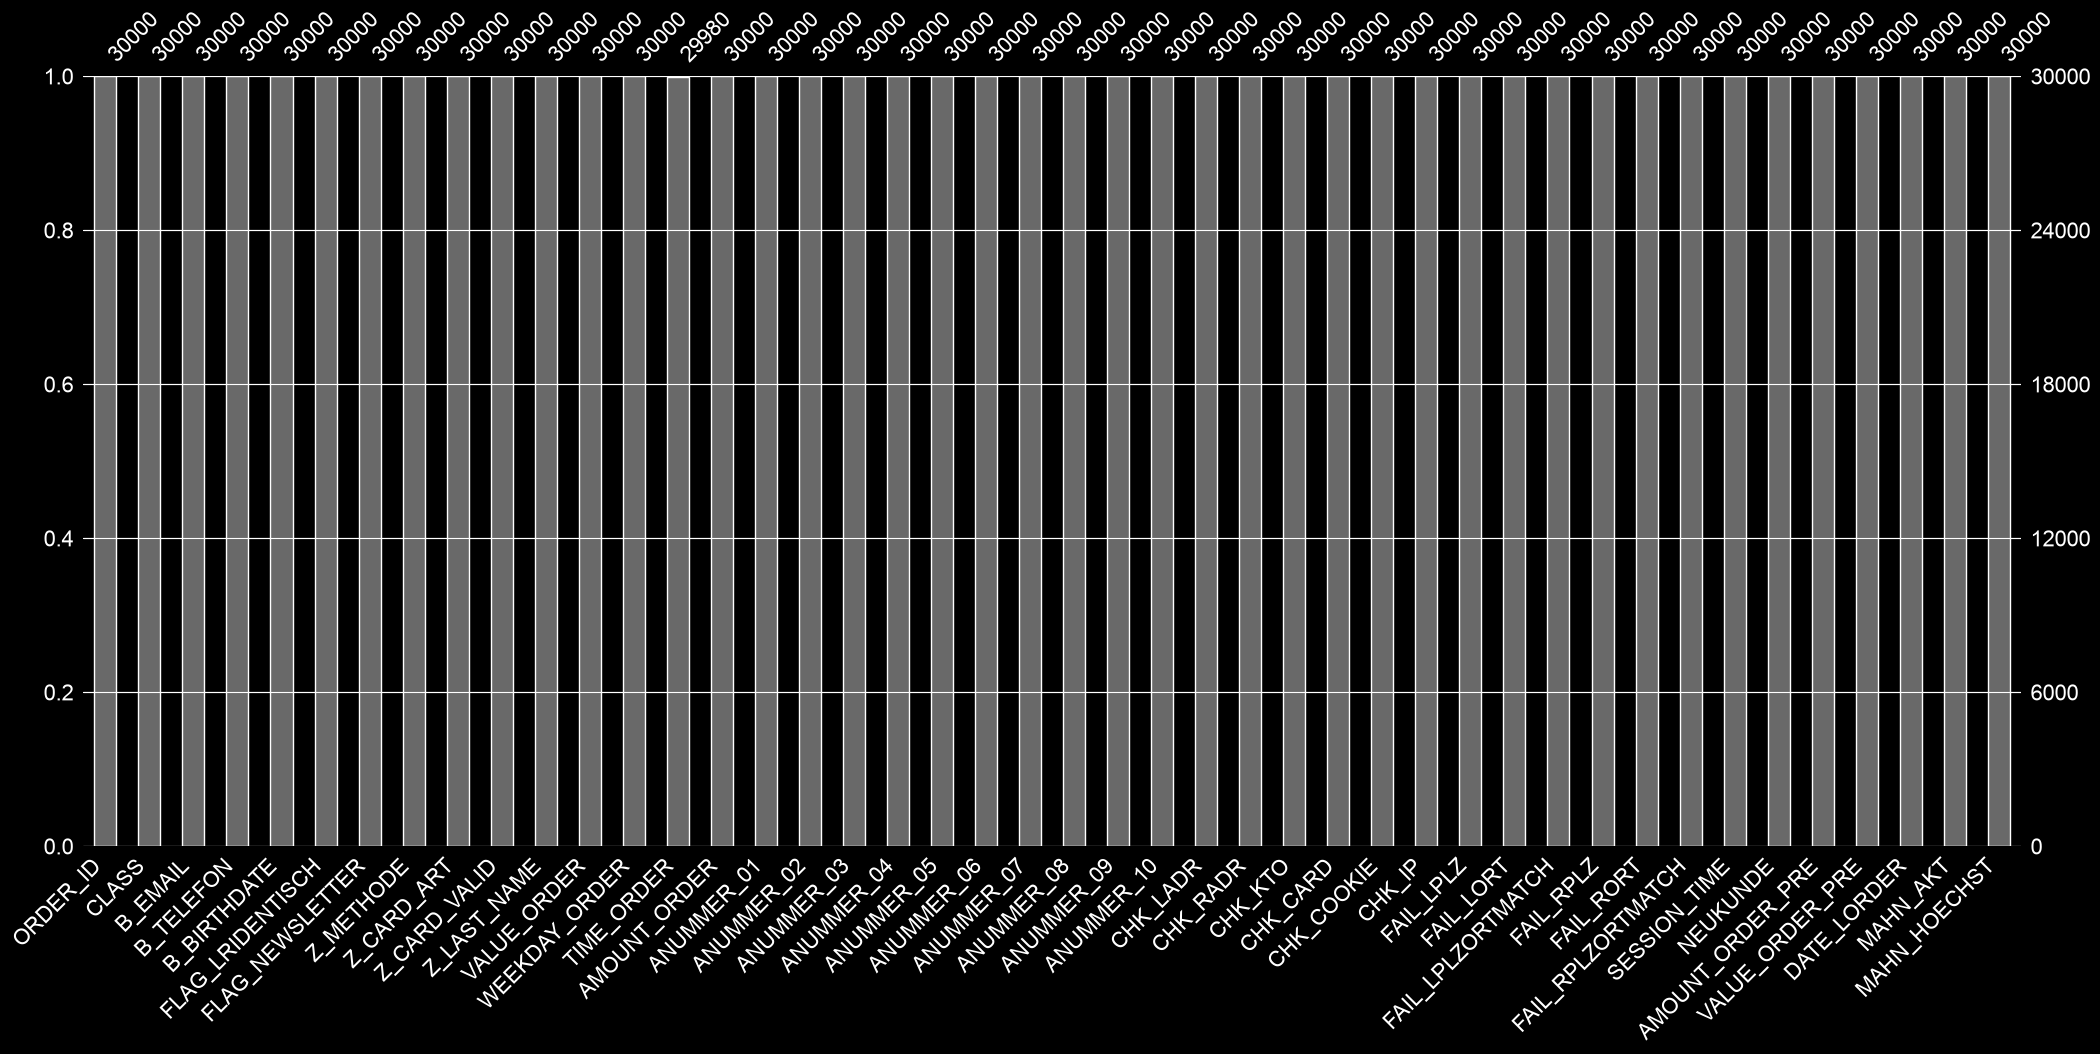

In [14]:
# visualize missing values
msno.bar(df)

In [15]:
# Replace "?" to missing values
df.replace("?", np.nan, inplace=True)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,Z_LAST_NAME,VALUE_ORDER,WEEKDAY_ORDER,TIME_ORDER,AMOUNT_ORDER,ANUMMER_01,ANUMMER_02,ANUMMER_03,ANUMMER_04,ANUMMER_05,ANUMMER_06,ANUMMER_07,ANUMMER_08,ANUMMER_09,ANUMMER_10,CHK_LADR,CHK_RADR,CHK_KTO,CHK_CARD,CHK_COOKIE,CHK_IP,FAIL_LPLZ,FAIL_LORT,FAIL_LPLZORTMATCH,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,NaN,5.2006,NaN,17.80,Saturday,9:13:00 AM,1,406811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,8,yes,0,0.00,NaN,NaN,NaN
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,yes,18.20,Wednesday,5:36:00 PM,1,600953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,yes,no,no,13,yes,0,0.00,NaN,NaN,NaN
2,49923,no,yes,no,4/3/1972,yes,no,check,NaN,12.2007,NaN,10.80,Friday,11:13:00 AM,1,406310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,3,yes,0,0.00,NaN,NaN,NaN
3,49924,no,no,yes,8/1/1966,yes,no,check,NaN,1.2007,NaN,54.50,Friday,2:07:00 AM,1,307359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,yes,no,no,no,no,no,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,yes,19.99,Tuesday,11:46:00 PM,1,200767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,16,yes,0,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,49821,no,yes,no,3/3/1981,yes,no,check,NaN,6.2005,NaN,18.20,Sunday,6:21:00 PM,1,406859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,10,no,1,40.83,3/9/2002,0,3
29996,49824,no,yes,no,2/21/1972,no,no,credit_card,Eurocard,5.2005,yes,12.60,Saturday,3:51:00 PM,1,206507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,10,no,2,52.84,6/3/2001,0,0
29997,49825,no,yes,no,6/11/1980,no,no,credit_card,Eurocard,11.2006,yes,32.80,Monday,10:37:00 AM,1,500767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,6,yes,0,0.00,NaN,NaN,NaN
29998,49828,no,yes,no,12/4/1980,no,no,credit_card,Visa,4.2005,yes,5.20,Sunday,1:52:00 AM,1,502611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,6,no,1,42.92,7/1/2001,0,0


In [16]:
df.isnull().sum()

ORDER_ID                 0
CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
S

In [24]:
# Extract Numeric Column
num_cols = df.select_dtypes(include = ["int64", "float64"])

num_cols.head()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
0,49917,5.2006,17.80,1,406811,8,0,0.00
1,49919,12.2007,18.20,1,600953,13,0,0.00
2,49923,12.2007,10.80,1,406310,3,0,0.00
3,49924,1.2007,54.50,1,307359,11,4,75.72
4,49927,12.2006,19.99,1,200767,16,0,0.00


In [26]:
# check for negative values
num_cols.describe()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25032.612933,6.680567,43.968058,1.442200,331860.254033,8.577900,0.606700,29.875652
std,14422.306098,3.468332,35.709431,0.921496,147310.846584,3.863448,0.765616,57.382732
min,1.000000,1.200500,5.200000,1.000000,100061.000000,1.000000,0.000000,0.000000
25%,12518.750000,3.200700,17.990000,1.000000,204159.000000,6.000000,0.000000,0.000000
50%,25095.500000,6.200700,34.500000,1.000000,401241.000000,9.000000,0.000000,0.000000
75%,37520.250000,10.200500,57.800000,2.000000,407703.000000,11.000000,1.000000,38.470000
max,50000.000000,12.200700,361.200000,9.000000,609725.000000,24.000000,6.000000,1047.800000


In [27]:
#Extract Categorical Column

cat_cols = df.select_dtypes(include = ["object", "category"])

## Exploratory Data Analysis

Univariate Analysis

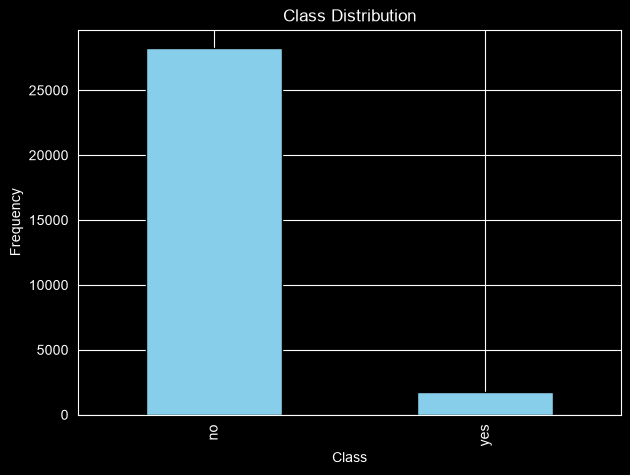

In [30]:
# Check Class Imbalance
count_class = cat_cols["CLASS"].value_counts()

# create bar chart
# Setting figure
plt.figure(figsize = (7,5))
# Plot the bar
count_class.plot(kind="bar", color='skyblue', edgecolor='black')

# Name bar
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

### Analysis

The target variable is highly imbalanced, with over 95% of customers classified as not high risk and fewer than 5% classified as high risk. This imbalance should be considered during model development, as accuracy alone may be misleading. Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a more reliable assessment of model performance.

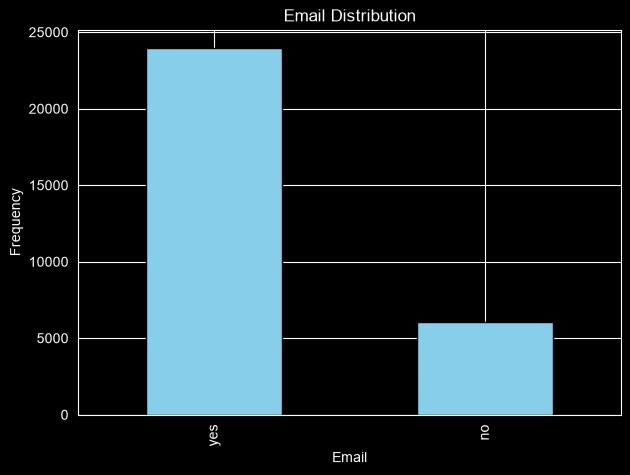

In [31]:
# Is it common for email to be submitted with an order?
count_email = df["B_EMAIL"].value_counts()
plt.figure(figsize = (7,5))
count_email.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Email Distribution")
plt.xlabel("Email")
plt.ylabel("Frequency")
plt.show()



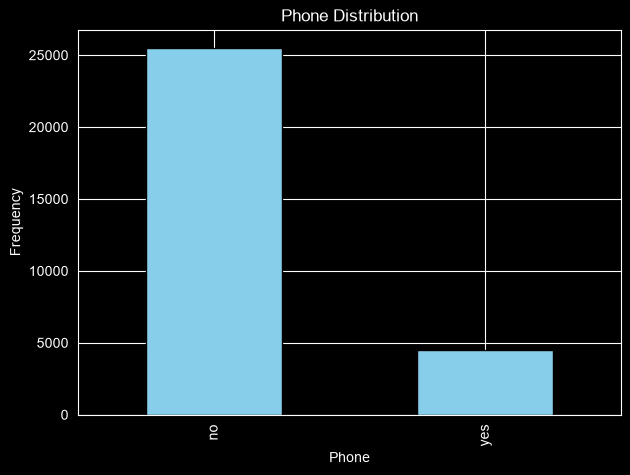

In [35]:
# Is it common for phone to be submitted with an order?
count_email = df["B_TELEFON"].value_counts()
plt.figure(figsize = (7,5))
count_email.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Phone Distribution")
plt.xlabel("Phone")
plt.ylabel("Frequency")
plt.show()

## Contact Details Feature Analysis

The majority of customers submitted an email address with their order, whereas fewer customers provided a phone number. At this stage, this analysis describes the overall distribution of these features only. Further bivariate analysis with the target variable (`CLASS`) will determine whether the presence or absence of an email address or phone number is associated with a higher likelihood of a high-risk order.

## Bivariate Analysis and Feature Selection